In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dropout,Flatten,Conv2D,MaxPooling2D,Dense,GlobalAveragePooling2D,BatchNormalization
from keras.regularizers import Regularizer
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import ModelCheckpoint

In [23]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()
X_train.shape,y_train.shape

((60000, 28, 28), (60000,))

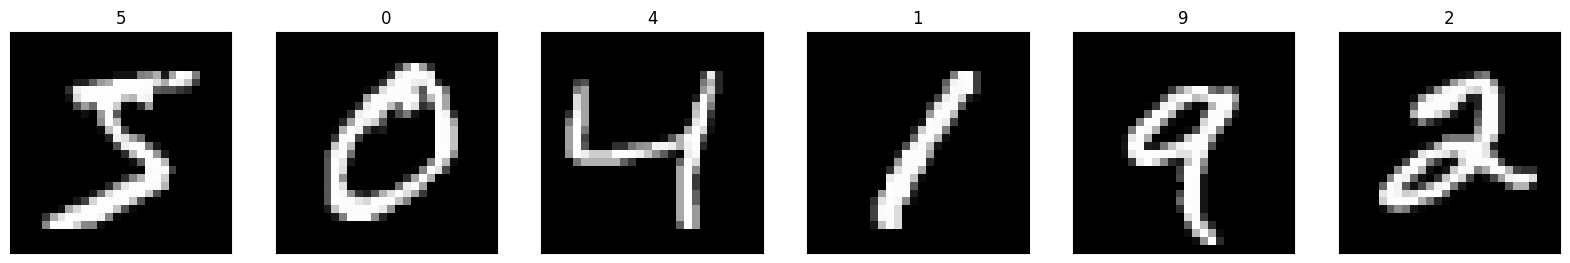

In [24]:
fig=plt.figure(figsize=(20,20))
for i in range(6):
    ax=fig.add_subplot(1,6,i+1,xticks=[],yticks=[])
    ax.imshow(X_train[i],cmap='gray')
    ax.set_title(str(y_train[i]))

### Preprocess i/p img: by rescale the images by dividing every pixel in every image by 255

In [25]:
X_valid,X_train=X_train[:5000]/255. ,X_train[5000:]/255.
y_valid,y_train=y_train[:5000],y_train[5000:] 
X_test=X_test/255.

In [26]:
y_train.ndim

1

In [27]:
y_train[:5]

array([7, 3, 4, 6, 1], dtype=uint8)

### Preprocess the labels :Encode categorical integer labels using One-Hot-Encoder

In [28]:
from tensorflow.keras.utils import to_categorical
#from sklearn.preprocessing import OneHotEncoder

num_classes=10
print(y_train[:10])
#encoder=OneHotEncoder()



y_train=keras.utils.to_categorical(y_train,num_classes)
y_test=keras.utils.to_categorical(y_test,num_classes)

print(y_train[:10])

[7 3 4 6 1 8 1 0 9 8]
[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]


In [29]:
y_train[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

### Reshape Data to fit our CNN (and input_shape)

In [30]:
X_train.shape[1]

28

In [31]:
img_rows,img_cols=28,28
X_train=X_train.reshape(X_train.shape[0],img_rows,img_cols,1)
X_test=X_test.reshape(X_test.shape[0],img_rows,img_cols,1)

input_shape=(img_rows,img_cols,1)

input_shape,X_train.shape



((28, 28, 1), (55000, 28, 28, 1))

## Define model Architecture

In [32]:
model=Sequential()

#CONV_1 
model.add(Conv2D(32,kernel_size=(3,3),padding='same',activation='relu',input_shape=(28,28,1)))

#POOL_1
model.add(MaxPooling2D(pool_size=(2,2)))

#CONVO_2
model.add(Conv2D(64,(3,3),padding='same',activation='relu'))

#POOl_2
model.add(MaxPooling2D(pool_size=(2,2)))

#Flatten here too many dimension so we want only classifiaction o/p
model.add(Flatten())

#FC_1
model.add(Dense(64,activation='relu'))

model.add(BatchNormalization())
model.add(Dropout(0.2))

#FC_2
model.add(Dense(10,activation='softmax'))

model.summary()


e:\Deep Learning\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,490 (861.29 KB)

 Trainable params: 220,362 (860.79 KB)

 Non-trainable params: 128 (512.00 B)

### compile the model

In [33]:
model.compile(loss='categorical_crossentropy',optimizer='rmsprop',metrics=['accuracy'])


### Train the model

In [36]:
checkpointer=ModelCheckpoint(filepath='model.weights.best.keras',verbose=1,save_best_only=True)

history=model.fit(X_train,y_train,batch_size=64,epochs=10,validation_data=(X_test,y_test),callbacks=[checkpointer],verbose=2,shuffle=True) # type: ignore

Epoch 1/10

Epoch 1: val_loss improved from None to 0.07140, saving model to model.weights.best.keras
860/860 - 11s - 13ms/step - accuracy: 0.9859 - loss: 0.0467 - val_accuracy: 0.9786 - val_loss: 0.0714
Epoch 2/10

Epoch 2: val_loss improved from 0.07140 to 0.03346, saving model to model.weights.best.keras
860/860 - 11s - 13ms/step - accuracy: 0.9903 - loss: 0.0320 - val_accuracy: 0.9884 - val_loss: 0.0335
Epoch 3/10

Epoch 3: val_loss improved from 0.03346 to 0.03141, saving model to model.weights.best.keras
860/860 - 11s - 13ms/step - accuracy: 0.9924 - loss: 0.0261 - val_accuracy: 0.9898 - val_loss: 0.0314
Epoch 4/10

Epoch 4: val_loss improved from 0.03141 to 0.02871, saving model to model.weights.best.keras
860/860 - 20s - 23ms/step - accuracy: 0.9934 - loss: 0.0209 - val_accuracy: 0.9904 - val_loss: 0.0287
Epoch 5/10

Epoch 5: val_loss did not improve from 0.02871
860/860 - 10s - 12ms/step - accuracy: 0.9950 - loss: 0.0165 - val_accuracy: 0.9899 - val_loss: 0.0345
Epoch 6/10

Ep

### Load the model with best classification accuracy on the test dataset

In [37]:
model.load_weights('model.weights.best.keras')


### Calculate the classification accuracy on test dataset

In [39]:
score=model.evaluate(X_test,y_test)
accuracy=100*score

accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9904 - loss: 0.0287


[0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844677090645,
 0.9904000163078308,
 0.02870844